# Q-Learning on MountainCar-v0 using Gymnasium

This notebook demonstrates **Q-learning** on the `MountainCar-v0` environment from the Python **Gymnasium** library.

MountainCar has a continuous observation space, so we first discretize the state into bins and then apply tabular Q-learning.

## Learning Objectives

- Understand the MountainCar environment
- Convert continuous states into discrete states
- Implement the Q-learning update rule
- Train an agent using epsilon-greedy exploration
- Plot training performance
- Test the trained agent


## 1. Install Required Libraries


In [2]:
!uv pip install gymnasium[classic-control] numpy matplotlib


Using Python 3.14.4 environment at: D:\Reading_Resources\Master\RIL\lab\.venv
Resolved 16 packages in 1.78s
 Downloaded pygame-ce
Prepared 4 packages in 2.27s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 5 packages in 3.54s
 + cloudpickle==3.1.2
 + farama-notifications==0.0.6
 + gymnasium==1.3.0
 + pygame-ce==2.5.7
 + typing-extensions==4.15.0


## 2. Import Libraries


In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

# For reproducibility
SEED = 42
np.random.seed(SEED)


## 3. Create and Inspect the Environment


In [5]:
env = gym.make("MountainCar-v0")

print("Environment:", env.spec.id)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)
print("Number of actions:", env.action_space.n)

env.close()


Environment: MountainCar-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Number of actions: 3


The action space has three discrete actions:

- `0`: Push left
- `1`: No push
- `2`: Push right

The observation has two values:

- Car position
- Car velocity


## 4. Define State Discretization


In [ ]:
env = gym.make("MountainCar-v0")

# Number of bins for each state variable: position and velocity
num_bins = np.array([20, 20])

# Lower and upper bounds of observation space
state_low = env.observation_space.low
state_high = env.observation_space.high

# Width of each bin
bin_width = (state_high - state_low) / num_bins

def discretize_state(state):
    """
    Convert a continuous state into a discrete state index.

    Parameters:
        state: array-like, [position, velocity]

    Returns:
        tuple: discrete state index, for example (10, 8)
    """
    #getting state positive 
    discrete_state = ((state - state_low) / bin_width).astype(int)
    #clipping the value under 0 to 19
    discrete_state = np.clip(discrete_state, 0, num_bins - 1)
    # making it tuple
    return tuple(discrete_state)

# Test discretization
sample_state, info = env.reset(seed=SEED)
print("Sample continuous state:", sample_state)
print("Sample discrete state:", discretize_state(sample_state))

env.close()


Sample continuous state: [-0.4452088  0.       ]
Sample discrete state: (np.int64(8), np.int64(10))


## 5. Initialize Q-Table and Hyperparameters


In [7]:
env = gym.make("MountainCar-v0")

# Q-table shape: position bins x velocity bins x number of actions
q_table_shape = (num_bins[0], num_bins[1], env.action_space.n)

# Initialize Q-table with small random negative values
q_table = np.random.uniform(low=-2, high=0, size=q_table_shape)

# Training hyperparameters
episodes = 10000
max_steps = 200

learning_rate = 0.1
discount_factor = 0.99

# Exploration hyperparameters
epsilon = 1.0
epsilon_decay = 0.9995
#The lower limit. It ensures the agent always retains a 1% chance of making random moves so it never completely stops exploring.
min_epsilon = 0.01

# Store training rewards
episode_rewards = []
steps_per_episode = []

print("Q-table shape:", q_table.shape)

env.close()


Q-table shape: (20, 20, 3)


## 6. Train the Q-Learning Agent

The Q-learning update rule is:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

Where:

- $\alpha$ is the learning rate
- $\gamma$ is the discount factor
- $r$ is the reward
- $s$ is the current state
- $a$ is the current action
- $s'$ is the next state


In [ ]:
env = gym.make("MountainCar-v0")

for episode in range(episodes):
    state, info = env.reset(seed=SEED + episode)
    discrete_state = discretize_state(state)

    total_reward = 0

    for step in range(max_steps):
        # Epsilon-greedy action selection
        #exploration for new values
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
        #otherwise exploitation from past experiences
            action = np.argmax(q_table[discrete_state])

        # Perform action
        next_state, reward, terminated, truncated, info = env.step(action)
        next_discrete_state = discretize_state(next_state)
        done = terminated or truncated

        # Current Q-value
        current_q = q_table[discrete_state + (action,)]

        if terminated:
            # Goal reached
            target_q = 0
        else:
            # Standard Q-learning target
            max_future_q = np.max(q_table[next_discrete_state])
            target_q = reward + discount_factor * max_future_q

        # Q-learning update
        new_q = current_q + learning_rate * (target_q - current_q)
        q_table[discrete_state + (action,)] = new_q

        discrete_state = next_discrete_state
        total_reward += reward

        if done:
            break

    # Decay exploration rate
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    steps_per_episode.append(step + 1)

    if (episode + 1) % 500 == 0:
        avg_reward = np.mean(episode_rewards[-500:])
        avg_steps = np.mean(steps_per_episode[-500:])
        print(
            f"Episode {episode + 1:5d} | "
            f"Average Reward: {avg_reward:8.2f} | "
            f"Average Steps: {avg_steps:6.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

env.close()


Episode   500 | Average Reward:  -200.00 | Average Steps: 200.00 | Epsilon: 0.779
Episode  1000 | Average Reward:  -200.00 | Average Steps: 200.00 | Epsilon: 0.606
Episode  1500 | Average Reward:  -199.96 | Average Steps: 199.96 | Epsilon: 0.472
Episode  2000 | Average Reward:  -199.84 | Average Steps: 199.84 | Epsilon: 0.368
Episode  2500 | Average Reward:  -197.91 | Average Steps: 197.91 | Epsilon: 0.286
Episode  3000 | Average Reward:  -195.62 | Average Steps: 195.62 | Epsilon: 0.223
Episode  3500 | Average Reward:  -191.85 | Average Steps: 191.85 | Epsilon: 0.174
Episode  4000 | Average Reward:  -181.56 | Average Steps: 181.56 | Epsilon: 0.135
Episode  4500 | Average Reward:  -178.40 | Average Steps: 178.40 | Epsilon: 0.105
Episode  5000 | Average Reward:  -173.08 | Average Steps: 173.08 | Epsilon: 0.082
Episode  5500 | Average Reward:  -175.30 | Average Steps: 175.30 | Epsilon: 0.064
Episode  6000 | Average Reward:  -166.92 | Average Steps: 166.92 | Epsilon: 0.050
Episode  6500 | 

## 7. Plot Rewards per Episode


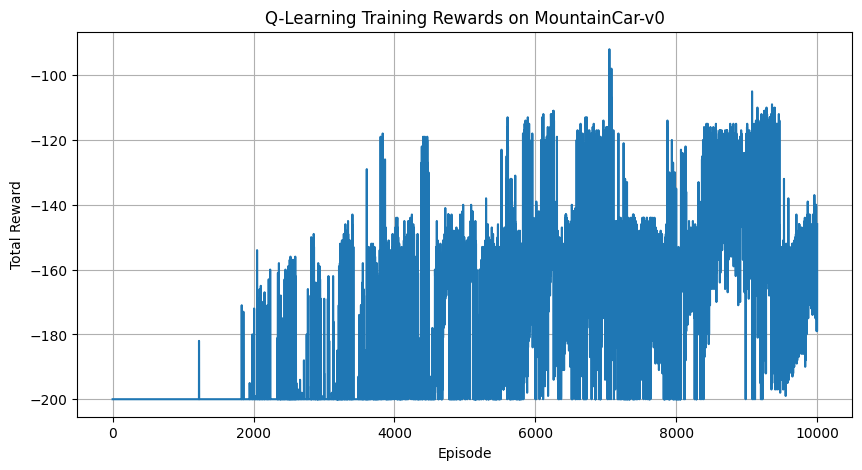

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Training Rewards on MountainCar-v0")
plt.grid(True)
plt.show()


## 8. Plot Moving Average Reward


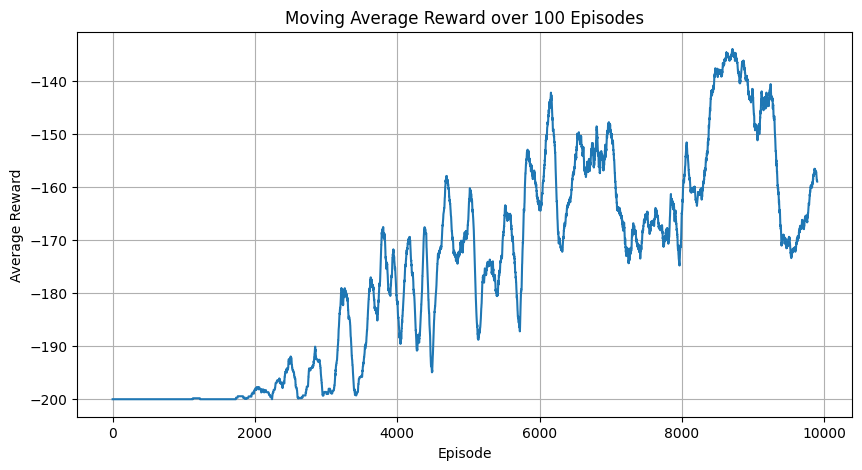

In [10]:
window = 100

moving_average_rewards = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average Reward over 100 Episodes")
plt.grid(True)
plt.show()


## 9. Plot Steps per Episode


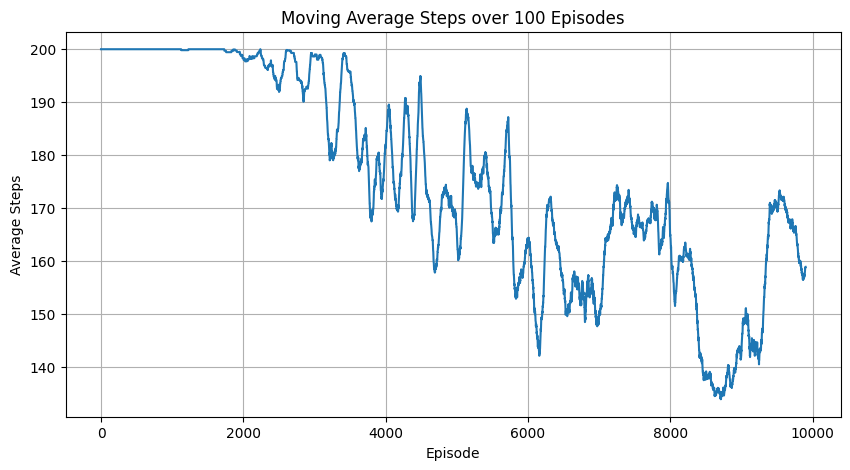

In [11]:
moving_average_steps = np.convolve(
    steps_per_episode,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average_steps)
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.title("Moving Average Steps over 100 Episodes")
plt.grid(True)
plt.show()


## 10. Test the Trained Agent Without Rendering


In [12]:
env = gym.make("MountainCar-v0")

test_episodes = 20
test_rewards = []
test_steps = []

for episode in range(test_episodes):
    state, info = env.reset(seed=1000 + episode)
    discrete_state = discretize_state(state)
    total_reward = 0

    for step in range(max_steps):
        action = np.argmax(q_table[discrete_state])
        next_state, reward, terminated, truncated, info = env.step(action)
        discrete_state = discretize_state(next_state)
        total_reward += reward

        if terminated or truncated:
            break

    test_rewards.append(total_reward)
    test_steps.append(step + 1)

env.close()

print("Test rewards:", test_rewards)
print("Average test reward:", np.mean(test_rewards))
print("Average test steps:", np.mean(test_steps))


Test rewards: [-154.0, -148.0, -159.0, -160.0, -164.0, -170.0, -162.0, -167.0, -168.0, -167.0, -161.0, -163.0, -158.0, -144.0, -159.0, -160.0, -164.0, -141.0, -151.0, -165.0]
Average test reward: -159.25
Average test steps: 159.25


## 11. Test the Trained Agent With Rendering

Run this cell only on a local machine where a display window is available.

In some online notebook environments, `render_mode="human"` may not work.


In [13]:
# Run this cell locally if rendering is supported

env = gym.make("MountainCar-v0", render_mode="human")

state, info = env.reset(seed=123)
discrete_state = discretize_state(state)
total_reward = 0

for step in range(max_steps):
    action = np.argmax(q_table[discrete_state])
    next_state, reward, terminated, truncated, info = env.step(action)
    discrete_state = discretize_state(next_state)
    total_reward += reward

    if terminated or truncated:
        break

env.close()

print("Rendered test reward:", total_reward)
print("Rendered test steps:", step + 1)


Rendered test reward: -149.0
Rendered test steps: 149


## 12. Save the Learned Q-Table


In [14]:
np.save("mountaincar_q_table.npy", q_table)
print("Q-table saved as mountaincar_q_table.npy")


Q-table saved as mountaincar_q_table.npy


## 13. Load the Q-Table Later


In [15]:
# To load the saved Q-table later, uncomment and run:

q_table = np.load("mountaincar_q_table.npy")
print("Q-table loaded successfully")


Q-table loaded successfully


## Lab Discussion Questions

1. Why do we need discretization for Q-learning in MountainCar?
2. What happens if we increase the number of bins?
3. What happens if epsilon decays too quickly?
4. Why does MountainCar usually receive negative rewards?
5. How is Q-learning different from policy-gradient methods such as REINFORCE?

## Summary

In this notebook, we implemented tabular Q-learning on MountainCar-v0. Since the environment has continuous states, we discretized position and velocity into bins. The agent learned a Q-table and improved its behavior through repeated interaction with the environment.
